In [117]:
import torch, os
import segmentation_models_pytorch as smp
import numpy as np
import nibabel as nib
import functools


dataset_dir = "Totalsegmentator_dataset_small_v201"
LUNG_LOBES = [
    "lung_upper_lobe_left", "lung_upper_lobe_right", "lung_middle_lobe_right",
    "lung_lower_lobe_left", "lung_lower_lobe_right",
]
HU_MIN, HU_MAX = -1000, 200
RANDOM_SEED = 0
np_rng = lambda: np.random.default_rng(RANDOM_SEED)

In [ ]:
def has_lung(case):
    for lobe in LUNG_LOBES:
        p_lobe = os.path.join(dataset_dir, case, "segmentations", f"{lobe}.nii.gz")
        if np.asarray(nib.load(p_lobe).dataobj).any():
            return True
    return False

idx_arr = sorted(filter(lambda x: "." not in x and has_lung(x), os.listdir(dataset_dir)))
np_rng().shuffle(idx_arr)
num_samples = len(idx_arr)

ratios = [0.60, 0.20, 0.20]
proportions = np.array(ratios) / np.sum(ratios)
cuts = np.round(np.cumsum(proportions)[:-1] * num_samples).astype(int)

train_idx, test_idx, val_idx = np.split(idx_arr, cuts)
print(len(train_idx), len(test_idx), len(val_idx))

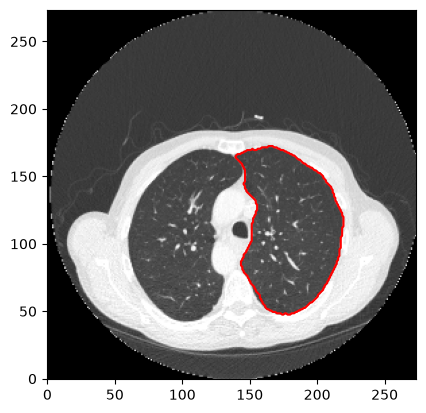

In [ ]:
import matplotlib.pyplot as plt

case_dir = os.path.join(dataset_dir, train_idx[0])
ct = nib.load(os.path.join(case_dir, "ct.nii.gz")).get_fdata()
seg = nib.load(os.path.join(case_dir, "segmentations", "lung_upper_lobe_right.nii.gz")).get_fdata()

k = seg.sum(axis=(0, 1)).argmax()
plt.imshow(ct[:, :, k].T, cmap="gray", vmin=-1350, vmax=150, origin="lower")
# plt.imshow(seg[:, :, k].T, origin="lower")
plt.contour(seg[:, :, k].T, levels=[0.5], colors="r")
plt.show()

In [ ]:
def normalize_hu(x):
    return (np.clip(x, HU_MIN, HU_MAX) - HU_MIN) / (HU_MAX - HU_MIN)

def crop(x, y, rng):
    return x, y

@functools.lru_cache(maxsize=10)
def load_lung(path):
    p_main = os.path.join(path, "ct.nii.gz")
    scan = nib.as_closest_canonical(nib.load(p_main)).get_fdata(dtype=np.float32)

    mask = np.zeros_like(scan, dtype=np.bool)
    for lobe in LUNG_LOBES:
        p_lobe = os.path.join(path, "segmentations", f"{lobe}.nii.gz")
        mask |= np.asarray(nib.as_closest_canonical(nib.load(p_lobe)).dataobj) > 0

    return normalize_hu(scan), mask


class LungDataset(torch.utils.data.Dataset):
    def __init__(self, id_list, dataset_dir) -> None:
        super().__init__()
        self._rng = np.random.default_rng(RANDOM_SEED)
        self._volumes = [load_lung(os.path.join(dataset_dir, case)) for case in id_list]
        self._slices = []
        for i, (_, mask) in enumerate(self._volumes):
            for k in np.flatnonzero(mask.any(axis=(0, 1))):
                self._slices.append((i, k))

    def __len__(self) -> int:
        return len(self._slices)

    def __getitem__(self, idx):
        i, k = self._slices[idx]
        scan, mask = self._volumes[i]
        x, y = crop(scan[:, :, k], mask[:, :, k], self._rng)
        return torch.from_numpy(x[None]), torch.from_numpy(y[None].astype(np.float32))


train_dataset = LungDataset(train_idx, dataset_dir)
test_dataset = LungDataset(test_idx, dataset_dir)
val_dataset = LungDataset(val_idx, dataset_dir)

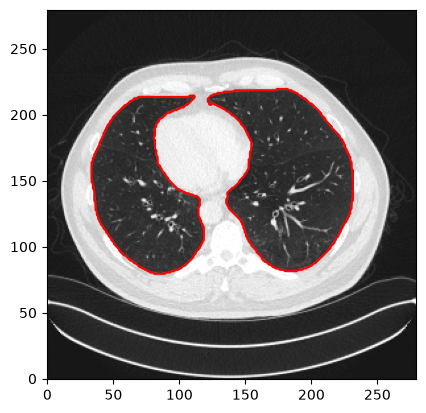

In [ ]:
x, y = train_dataset[np.random.randint(low=0, high=len(train_dataset))]
plt.imshow(x[0].T, cmap="gray", origin="lower")
plt.contour(y[0].T, levels=[0.5], colors="r")
plt.show()